In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("../data/raw/ride/uber_lyft_boston.csv")
print(df.shape)
df.head()

(693071, 10)


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  str    
 2   time_stamp        693071 non-null  int64  
 3   destination       693071 non-null  str    
 4   source            693071 non-null  str    
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  float64
 7   id                693071 non-null  str    
 8   product_id        693071 non-null  str    
 9   name              693071 non-null  str    
dtypes: float64(3), int64(1), str(6)
memory usage: 116.7 MB


In [6]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({"nulls": null_counts, "pct": null_pct})
null_summary[null_summary["nulls"] > 0].sort_values("pct", ascending=False)

,nulls,pct
price,55095,7.95


In [7]:
df[["cab_type", "name", "price", "distance", "surge_multiplier"]].describe(include="all")

,cab_type,name,price,distance,surge_multiplier
count,693071,693071,637976.000000,693071.000000,693071.000000
unique,2,13,NaN,NaN,NaN
top,Uber,UberXL,NaN,NaN,NaN
freq,385663,55096,NaN,NaN,NaN
mean,NaN,NaN,16.545125,2.189430,1.013870
std,NaN,NaN,9.324359,1.138937,0.091641
min,NaN,NaN,2.500000,0.020000,1.000000
25%,NaN,NaN,9.000000,1.280000,1.000000
50%,NaN,NaN,13.500000,2.160000,1.000000
75%,NaN,NaN,22.500000,2.920000,1.000000


surge_multiplier
1.00    672096
1.25     11085
1.50      5065
1.75      2420
2.00      2239
2.50       154
3.00        12
Name: count, dtype: int64


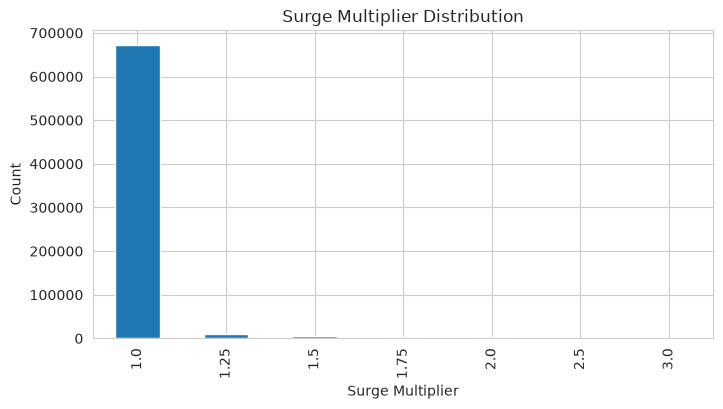

In [8]:
print(df["surge_multiplier"].value_counts().sort_index())

plt.figure(figsize=(8, 4))
df["surge_multiplier"].value_counts().sort_index().plot(kind="bar")
plt.title("Surge Multiplier Distribution")
plt.xlabel("Surge Multiplier")
plt.ylabel("Count")
plt.show()


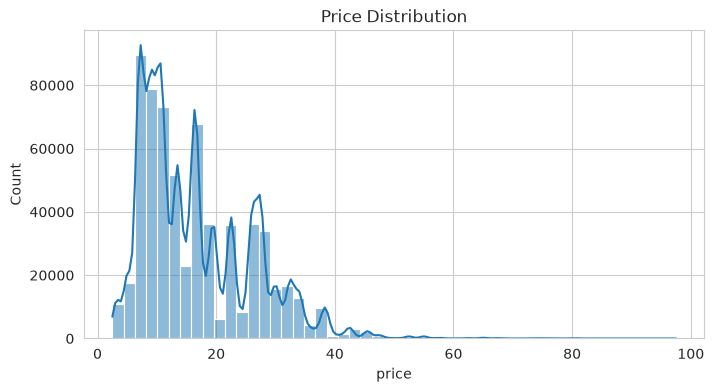

count    637976.000000
mean         16.545125
std           9.324359
min           2.500000
25%           9.000000
50%          13.500000
75%          22.500000
max          97.500000
Name: price, dtype: float64


In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df["price"].dropna(), bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

print(df["price"].describe())

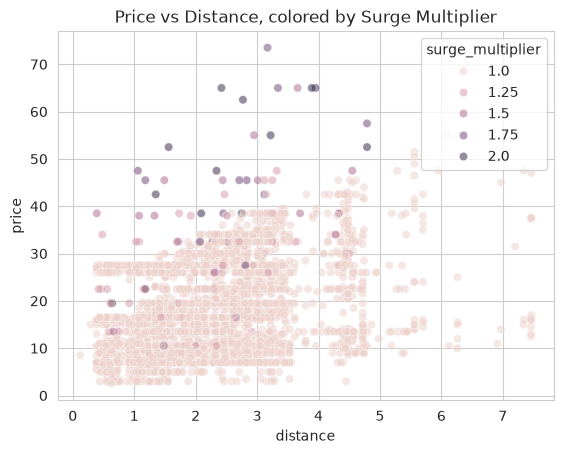

In [10]:
sample = df.sample(min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample, x="distance", y="price", hue="surge_multiplier", alpha=0.5)
plt.title("Price vs Distance, colored by Surge Multiplier")
plt.show()


KeyError: "None of [Index(['timestamp', 'hour', 'day', 'month', 'datetime'], dtype='str')] are in the [columns]"